# 4. Implementing Matrix Factorization


### (a) Image Reconstruction

## **Objective 1**  
Reconstruct an image with missing pixel values using **Gradient Descent**. Perform the following two cases:  
1. A rectangular block of size 30×30 is missing.  
2. A random subset of 900 (30×30) pixels is missing.  

Tasks:  
- Select an appropriate rank `r`.  
- Run Gradient Descent until convergence.  
- Plot:  
  - The selected missing regions,  
  - The original image,  
  - The reconstructed image.  
- Compute:  
  - **RMSE** (predicted vs ground truth),  
  - **Peak SNR**.  


Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torchvision

Device Set Up

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():  # For Mac GPUs
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Working on device:", device)

Working on device: cpu


Setting the Random Seed

Setting a random seed ensures reproducibility by making all random operations—like matrix initialization and pixel masking—produce the same results every time. This allows consistent, verifiable experiments

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

Loading the Image

Colored image shape (C,H,W): torch.Size([3, 337, 600])
Min pixel value: 0.0
Max pixel value: 1.0


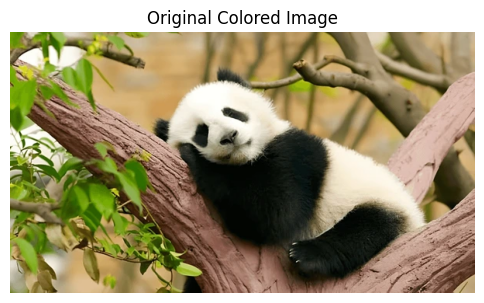

In [7]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0


color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\panda.jpg')  # shape: [C, H, W]
color_img = normalize_image(color_img)
print("Colored image shape (C,H,W):", color_img.shape)
print("Min pixel value:", color_img.min().item())
print("Max pixel value:", color_img.max().item())

# Display colored image
plt.figure(figsize=(6,6))
plt.imshow(color_img.permute(1,2,0))  # convert [C,H,W] -> [H,W,C] for matplotlib
plt.title("Original Colored Image")
plt.axis('off')
plt.show()

Converting to Grayscale

Grayscale image shape: torch.Size([337, 600])


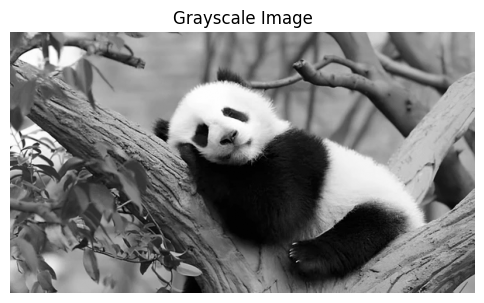

In [ ]:
gray_img = color_img.mean(dim=0)  # average over channel dimension -> [H,W]
print("Grayscale image shape:", gray_img.shape)

plt.figure(figsize=(6,6))
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

# Convert to torch tensor for reconstruction
X = gray_img.clone()  # [H,W] tensor now it is ready for operations like matrix factorization

Move the Image tensor to device using .to(device) argument

In [9]:
X = X.to(device)

## **Objective 2**  
Reconstruct the same images (Case 1 and 2) using **Alternating Least Squares (ALS)** instead of Gradient Descent.  

Tasks:  
- Write your own ALS function using [`torch.linalg.lstsq`](https://pytorch.org/docs/stable/generated/torch.linalg.lstsq.html).  
- Compare reconstructed results and metrics with the Gradient Descent approach.  
